# Option analytics: can what the options market prices rank the stock

Every other case study in this book builds its features from the history of the thing it is
trying to predict - past returns, past volatility, past volume. This one does not. Its features
come from the options written on each stock, and an option price is not a record of what
happened. It is what someone was willing to pay today for a claim on what happens next. Implied
volatility, the skew between puts and calls, the slope of the term structure, the gap between
implied and realized variance: each is a statement the market is making about the future.

That makes the question here sharper than "do these features work". The features are already
forecasts, made by people with money at stake. If a forecast that good does not rank the
cross-section, the interesting part is understanding what it is a forecast *of*.

The design matrix has the redundancy every case study in this book has - implied volatility
appears at three tenors and again as a rank, a percentile and two z-scores; the variance risk
premium appears as a level, a rank and a z-score - so the penalty sweep has the same job here as
elsewhere. **Regularization** adds a penalty on coefficient size to the fitting objective, and
how much to apply is an empirical question this notebook answers by trying ten orders of
magnitude of it.

Two folds, and one of them validates on 2020. The usable history of this option analytics
dataset is short, so `05_evaluation` set a walk-forward schedule whose validation windows are
2019 and 2020. Whatever the models find or fail to find, they are being asked about a period
containing the fastest volatility shock in the sample.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same stocks, the same dates and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Say what a feature set of option-implied quantities is a forecast of, and why that is not the
  same thing as the quantity this notebook asks it to rank.
- Read a grid in which no configuration clears zero, and say what that is and is not evidence
  for.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds and screened
the individual features.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`14_backtest`](14_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to this feature set; that ranking decides nothing.

In [1]:
"""Fit the declared option-analytics linear-model population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_5d"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "sp500_equity_option_analytics-linear-validation-v1"

In [3]:
study = open_study(
    "sp500_equity_option_analytics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines five in `config/setup.yaml`.
`fwd_ret_5d`, the stock's total return over the five trading days after the decision date, is
the primary one - the horizon the strategy chapters trade. `fwd_ret_10d` is the same idea over
a longer horizon, `fwd_ret_risk_adj_5d` divides the move by a volatility estimate, and
`fwd_dir_5d` and `fwd_dir_10d` are classification variants that ask for the direction rather
than the size.

**This notebook fits one label per run.** `LABEL` above selects it, and every choice below
follows from that one setting, because each label has its own training menu at
`config/training/{label}.yaml`. The menu lists, family by family, the named configurations to
fit for that label. A label with no menu file has nothing declared and nothing to fit; these
are the ones that declare linear models.

In [4]:
declared_labels(study, "linear")

('fwd_dir_10d',
 'fwd_dir_5d',
 'fwd_ret_10d',
 'fwd_ret_5d',
 'fwd_ret_risk_adj_5d')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for `LABEL`, with each name resolved to the estimator class it names
and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_5d""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_5d""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_5d""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_5d""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_5d""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_5d""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""fwd_ret_5d""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""fwd_ret_5d""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which stock-date pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of stocks with a usable option surface, and the
  number of stock-date pairs to be predicted. Every configuration here reads the same feature
  matrix, so a row that differs is a configuration being measured on a different sample from
  its neighbours, and its results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,date,date
"""enet_f0.015""",48,549,194813,2,2019-01-07,2020-12-23
"""enet_f0.03""",48,549,194813,2,2019-01-07,2020-12-23
"""enet_f0.08""",48,549,194813,2,2019-01-07,2020-12-23
"""enet_f0.2""",48,549,194813,2,2019-01-07,2020-12-23
"""enet_f0.35""",48,549,194813,2,2019-01-07,2020-12-23
…,…,…,…,…,…,…
"""ridge_a1000.0""",48,549,194813,2,2019-01-07,2020-12-23
"""ridge_a10000.0""",48,549,194813,2,2019-01-07,2020-12-23
"""ridge_a100000.0""",48,549,194813,2,2019-01-07,2020-12-23


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `14_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

28 configurations: 0 folds fitted, 56 reused
population sp500_equity_option_analytics-linear-validation-v1: 28 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_5d"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: on each validation date, rank the stocks by the model's prediction, rank them by
the return they went on to earn, correlate the two rankings, and average that daily correlation
over the validation period. It measures whether the model ranks stocks correctly, on a scale
where zero is no relationship, positive means the ranking points the right way, and negative
means it points the wrong way.

`ic_n_days` is how many validation dates produced a defined correlation. A model whose
coefficients collapse to one or two features predicts nearly the same value for every stock on
some dates; a constant has no rank correlation with anything, so those dates would contribute
nothing and that configuration's IC would be an average over a smaller sample than its
neighbours'. `full_coverage` marks the configurations measured on all of them.

In [8]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("ic_mean", descending=True)
    .join(configs.select("config_name", "model_class", "params"), on="config_name", how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,f64,f64,f64,bool
"""enet_f0.08""","""ElasticNet""","""alpha_frac=0.08, l1_ratio=0.5,…",-0.002384,0.017745,497.0,true
"""lasso_f0.08""","""Lasso""","""alpha_frac=0.08, max_iter=5000""",-0.002384,0.017737,497.0,true
"""lasso_f0.35""","""Lasso""","""alpha_frac=0.35, max_iter=5000""",-0.00245,0.011077,497.0,true
"""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…",-0.002454,0.011081,497.0,true
"""enet_f0.2""","""ElasticNet""","""alpha_frac=0.2, l1_ratio=0.5, …",-0.003099,0.015869,497.0,true
…,…,…,…,…,…,…
"""ols""","""LinearRegression""","""defaults""",-0.004262,0.012274,497.0,true
"""ridge_a0.001""","""Ridge""","""alpha=0.001""",-0.004262,0.012274,497.0,true
"""ridge_a100000.0""","""Ridge""","""alpha=100000.0""",-0.004878,0.016201,497.0,true


### How the penalty grid ranks

Only the configurations measured on all `full_days` validation dates are charted. The zero line
is the reference that matters: a bar below it is a model whose ranking pointed the wrong way out
of sample.

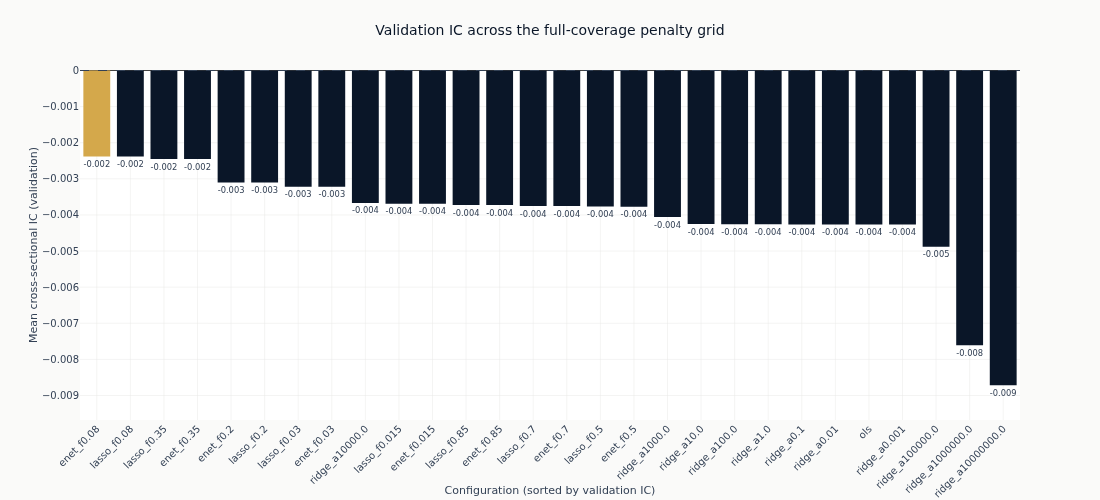

In [9]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.3f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending, against a dashed zero line. {leader['config_name']} "
    f"({compact(leader['params'])}) is highlighted in amber at the top of the ranking at IC "
    f"{leader['ic_mean']:+.3f}. Every bar falls below the zero line and the spread between the "
    "top and the bottom of the grid is a few thousandths.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

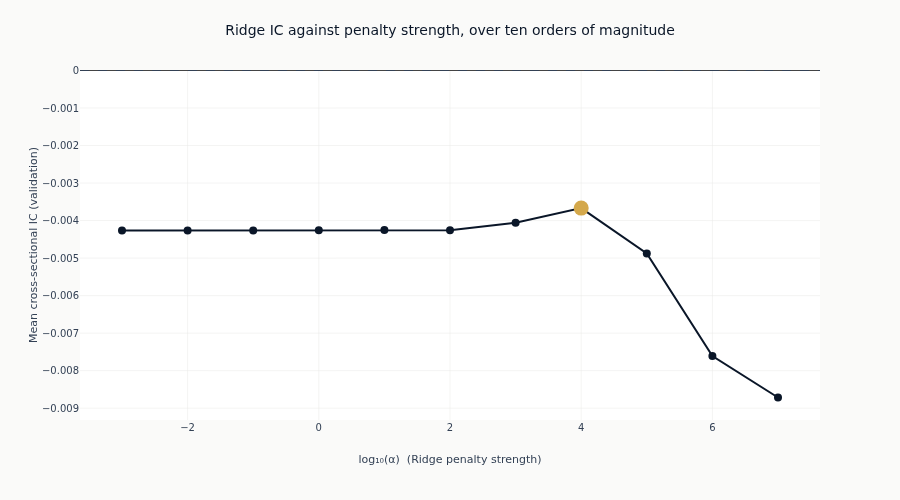

In [10]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(
        alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64),
    )
    .drop_nulls("alpha")
    .sort("alpha")
)
if ridge.height:
    log_alpha = np.log10(ridge.get_column("alpha").to_numpy())
    ridge_ic = ridge.get_column("ic_mean").to_numpy()
    peak = int(np.argmax(ridge_ic))

    fig_alpha = go.Figure(
        go.Scatter(
            x=log_alpha,
            y=ridge_ic,
            mode="lines+markers",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=8, color=COLORS["blue"]),
        )
    )
    fig_alpha.add_trace(
        go.Scatter(
            x=[log_alpha[peak]],
            y=[ridge_ic[peak]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
    fig_alpha.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over ten orders of magnitude",
        height=500,
        width=900,
        showlegend=False,
        margin=dict(t=70),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of the "
        "Ridge penalty, against a dashed zero line. The curve is flat and below zero across most of "
        f"the range, with its maximum at 1e{int(round(log_alpha[peak]))} marked in amber, and falls "
        "further at the strongest penalties.",
    )
else:
    print(
        f"{LABEL} declares no Ridge configurations, so there is no penalty sweep to trace. "
        f"Which estimators this section can show is decided by the menu at "
        f"config/training/{LABEL}.yaml."
    )

## 5. What to notice

**No configuration clears zero, and the whole grid fits inside a few thousandths.** That is the
result, and the top row of the table is not a finding - it is the least negative member of a set
that contains nothing. The comparison that matters is against zero, and nothing here reaches it.
A notebook that sorted the table and reported the first line would be describing an ordering
with no content.

**The penalty is not doing anything legible either.** Ridge is flat across most of the range and
falls at the strongest settings, and the L1 configurations sit in the same narrow band. When a
sweep over ten orders of magnitude moves the metric by less than the spread between neighbouring
configurations, the reading is that there is no signal for the penalty to trade off against
noise - not that some intermediate penalty is the right one.

**These features are a forecast of dispersion, not of direction.** That is the explanation worth
taking away, and it is a property of what an option price is. Implied volatility says how wide
the market expects the distribution to be; skew says how asymmetric; the term structure says how
that changes with horizon; the variance risk premium says how much the market charges for
bearing it. None of them is a statement about the *mean* of the distribution, which is what a
forward return is. Asking a well-informed forecast of width to rank assets by their forward
return is asking it a question it was not making a claim about. `05_evaluation` screens these
features one at a time and says the same thing before any model is fitted.

**Two folds, and one of them is 2020.** Half the validation evidence comes from a year in which
implied volatility across every name moved together and by more than in the rest of the sample
combined. A cross-sectional ranking asks which stock will out-return which, and that question
gets harder when one factor is moving everything. Nothing above separates a weak feature set
from an unrepresentative window, and with two folds nothing can.

**What this does not rule out.** It says nothing about whether these features forecast the
*volatility* of these stocks, which is the quantity they are actually about and which the risk
chapters use them for. It says nothing about a strategy that trades the options rather than the
underlying, which is the question the `sp500_options` case study asks. And a linear model can only represent a weighted sum of these columns, so it cannot express
something like "skew matters when the term structure is inverted" unless someone builds that
column first.

**None of this selects anything.** IC measures whether predictions rank stocks correctly, not
whether a strategy trading them makes money after costs and turnover. Selection is on validation
backtest Sharpe over the population this notebook just published, and it happens in
[`14_backtest`](14_backtest.ipynb). What this notebook establishes is that the linear family
enters that comparison with nothing to defend.

**Known limitations.** The IC here is an average of daily rank correlations with no adjustment
for the serial dependence that overlapping five-day returns create, so it is a ranking
diagnostic rather than a test. The grid is a one-dimensional sweep of penalty strength at fixed
features and fixed folds. And every number here is measured on the validation folds, which have
been read many times over by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting finds structure a linear model
cannot represent at all. The interaction named above is the concrete version of that question,
and it is worth being clear in advance what a better result there would mean: with this many
features and two folds, a tree ensemble that clears zero where the linear grid did not has
either found a real interaction or fitted the 2020 window, and telling those apart is what
[`13_model_analysis`](13_model_analysis.ipynb) is for.